# VGG16 (View-Independent) Image Preprocessing Pipelines Experiments

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications import VGG16
import cv2
import sys
import time
import os

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 189 (delta 70), reused 154 (delta 57), pack-reused 0 (from 0)
Receiving objects: 100% (189/189), 3.08 MiB | 23.68 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessing_pipelines import *
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.view_independent.dataset import generate_dataset
from src.models.view_independent.vgg16CNN import create_vgg16_model
from src.models.model_functions import compile_model
from src.visualizations import *

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training, validation and testing datasets (containing images)
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/test_dataset.zip" -d "/content/extracted_test_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training, validation and testing metadata from csv files and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")
test_df = pd.read_csv(dataset_root + "/test_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)
test_df['new_image_path'] = test_df['image_path'].apply(update_image_path_testing)

In [ ]:
# Label encoding all dataframes
train_df['pathology'] = train_df['pathology'].map({'BENIGN': 0.0, 'MALIGNANT': 1.0})
val_df['pathology'] = val_df['pathology'].map({'BENIGN': 0.0, 'MALIGNANT': 1.0})
test_df['pathology'] = test_df['pathology'].map({'BENIGN': 0.0, 'MALIGNANT': 1.0})

In [ ]:
# Print pathology distribution in each set
print(train_df['pathology'].value_counts())
print(val_df['pathology'].value_counts())
print(test_df['pathology'].value_counts())

pathology
0.0    1371
1.0     904
Name: count, dtype: int64
pathology
0.0    357
1.0    230
Name: count, dtype: int64
pathology
0.0    382
1.0    322
Name: count, dtype: int64


In [ ]:
# No. of testing image samples
testing_images_count = len(test_df)

# True pathology labels
true_pathology = test_df['pathology']

# Convert true pathology series to numpy array
true_pathology_np = true_pathology.to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/image_preprocessing_results.csv"

## P0 Image Preprocessing Pipeline Experiment

**Baseline Image Preprocessing Pipeline**

* Resizing
* Normalization

In [ ]:
# Select the p0 image preprocessor function from the image preprocessor dictionary
p0 = IMAGE_PREPROCESSORS['P0']

In [ ]:
# Create a tf.data dataset with p0 image preprocessing
train_dataset_p0 = generate_dataset(train_df, 32, p0, 'vgg16', training=True)
val_dataset_p0 = generate_dataset(val_df, 32, p0, 'vgg16', training=False)
test_dataset_p0 = generate_dataset(test_df, 32, p0, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p0 pipeline
vgg16_p0 = create_vgg16_model()
vgg16_p0 = compile_model(vgg16_p0)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# Train VGG16 with training dataset for p0 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p0
train_start_p0 = time.time()

# VGG16 with p0 training for 20 epochs
vgg16_p0.fit(train_dataset_p0, validation_data=val_dataset_p0, epochs=20)

# Memory used in p0
peak_memory_p0 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p0
train_end_p0 = time.time()

# Total training time for p0 in minutes
training_time_p0 = (train_end_p0 - train_start_p0)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 61s 196ms/step - accuracy: 0.5560 - auc: 0.5007 - loss: 0.7238 - precision: 0.3575 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4973 - val_loss: 0.6744 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 192ms/step - accuracy: 0.5780 - auc: 0.5054 - loss: 0.6837 - precision: 0.4136 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.5040 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 196ms/step - accuracy: 0.5881 - auc: 0.5081 - loss: 0.6789 - precision: 0.4108 - recall: 0.0841 - val_accuracy: 0.6082 - val_auc: 0.4962 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 58s 201ms/step - accuracy: 0.5829 - auc: 0.4953 - loss: 0.6796 - precision: 0.3256 - recall: 0.0465 - val_accuracy: 0.6082 - val_auc: 0.4958 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P0 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p0

# Prediction start time
predict_start_p0 = time.time()

# VGG16 with p0 predictions
prediction_probs_p0 = vgg16_p0.predict(test_dataset_p0)

# Prediction end time
predict_end_p0 = time.time()

# Total prediction time for p0 in seconds
prediction_time_p0 = predict_end_p0 - predict_start_p0

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step


In [ ]:
# Evaluation metrics for VGG16 with p0
eval_metrics_p0 = vgg16_p0.evaluate(test_dataset_p0, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.5426 - auc: 0.5039 - loss: 0.6945 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p0 = np.where(prediction_probs_p0 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p0 true and predicted values
tn_p0, fp_p0, fn_p0, tp_p0 = confusion_matrix(true_pathology, predictions_p0).ravel()

# Compute specificity using CM
specificity_p0 = tn_p0 / (tn_p0 + fp_p0)

# Compute F1 Score using recall and precision
f1_score_p0 = 0.0
if eval_metrics_p0['precision'] + eval_metrics_p0['recall'] != 0.0:
  f1_score_p0 = (2 * eval_metrics_p0['precision'] * eval_metrics_p0['recall']) / (eval_metrics_p0['precision'] + eval_metrics_p0['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p0 = vgg16_p0.count_params()

In [ ]:
# Generate a results dataframe for results of p0 experiment
results_p0 = generate_results_df('VGG16', 'View_Independent', 'P0', eval_metrics_p0, specificity_p0, f1_score_p0, training_time_p0, prediction_time_p0, peak_memory_p0, vgg16_params_p0)

# Store p0 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p0)

Stored results for 0    P0
Name: image_preprocessing_pipeline, dtype: object pipeline


### P0 Image Preprocessing Graphs

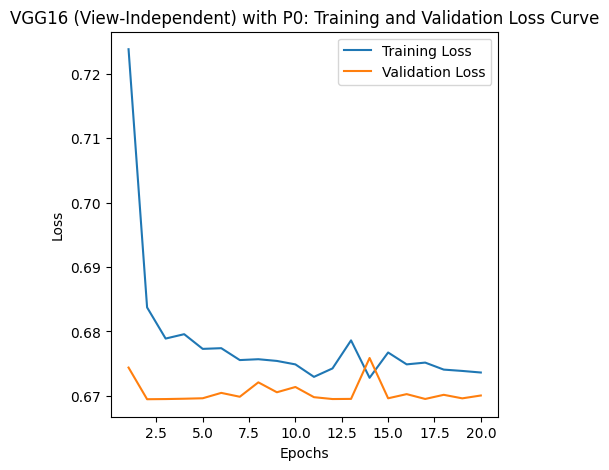

In [ ]:
# Training-Validation Loss curve for P0 pipeline
plot_training_validation_loss(vgg16_p0.history, 'VGG16 (View-Independent)', 'P0')

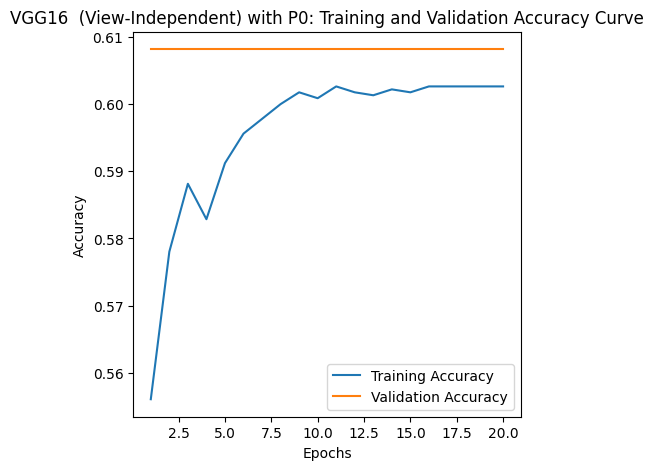

In [ ]:
# Training-Validation Accuracy curve for P0 pipeline
plot_training_validation_accuracy(vgg16_p0.history, 'VGG16  (View-Independent)', 'P0')

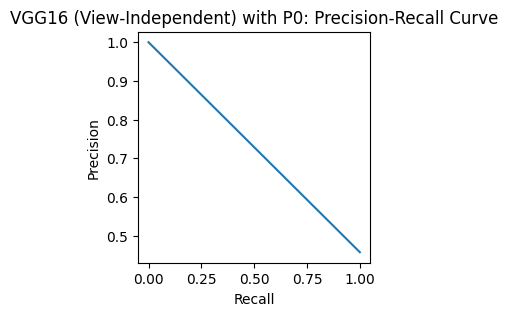

In [ ]:
# Precision-Recall curve for P0 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p0, 'VGG16 (View-Independent)', 'P0')

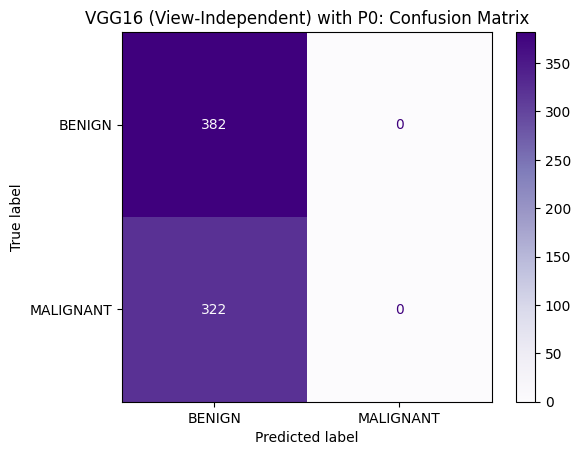

In [ ]:
# Confusion matrix for P0 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p0, 'VGG16 (View-Independent)', 'P0')

## P1 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* Normalization

In [ ]:
# Select the p1 image preprocessor function from the image preprocessor dictionary
p1 = IMAGE_PREPROCESSORS['P1']

In [ ]:
# Create a tf.data dataset with p1 image preprocessing
train_dataset_p1 = generate_dataset(train_df, 32, p1, 'vgg16', training=True)
val_dataset_p1 = generate_dataset(val_df, 32, p1, 'vgg16', training=False)
test_dataset_p1 = generate_dataset(test_df, 32, p1, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p1 pipeline
vgg16_p1 = create_vgg16_model()
vgg16_p1 = compile_model(vgg16_p1)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p1 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p1
train_start_p1 = time.time()

# VGG16 with p1 training for 20 epochs
vgg16_p1.fit(train_dataset_p1, validation_data=val_dataset_p1, epochs=20)

# Memory used in p1
peak_memory_p1 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p1
train_end_p1 = time.time()

# Total training time for p1 in minutes
training_time_p1 = (train_end_p1 - train_start_p1)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 201ms/step - accuracy: 0.5560 - auc: 0.5007 - loss: 0.7238 - precision: 0.3575 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4973 - val_loss: 0.6744 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 191ms/step - accuracy: 0.5780 - auc: 0.5054 - loss: 0.6837 - precision: 0.4136 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.5040 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 202ms/step - accuracy: 0.5881 - auc: 0.5081 - loss: 0.6789 - precision: 0.4108 - recall: 0.0841 - val_accuracy: 0.6082 - val_auc: 0.4962 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 211ms/step - accuracy: 0.5829 - auc: 0.4953 - loss: 0.6796 - precision: 0.3256 - recall: 0.0465 - val_accuracy: 0.6082 - val_auc: 0.4958 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P1 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p1

# Prediction start time
predict_start_p1 = time.time()

# VGG16 with p1 predictions
prediction_probs_p1 = vgg16_p1.predict(test_dataset_p1)

# Prediction end time
predict_end_p1 = time.time()

# Total prediction time for p1 in seconds
prediction_time_p1 = predict_end_p1 - predict_start_p1

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step


In [ ]:
# Evaluation metrics for VGG16 with p1
eval_metrics_p1 = vgg16_p1.evaluate(test_dataset_p1, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.5426 - auc: 0.5039 - loss: 0.6945 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p1 = np.where(prediction_probs_p1 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p1 true and predicted values
tn_p1, fp_p1, fn_p1, tp_p1 = confusion_matrix(true_pathology, predictions_p1).ravel()

# Compute specificity using CM
specificity_p1 = tn_p1 / (tn_p1 + fp_p1)

# Compute F1 Score using recall and precision
f1_score_p1 = 0.0
if eval_metrics_p1['precision'] + eval_metrics_p1['recall'] != 0.0:
  f1_score_p1 = (2 * eval_metrics_p1['precision'] * eval_metrics_p1['recall']) / (eval_metrics_p1['precision'] + eval_metrics_p1['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p1 = vgg16_p1.count_params()

In [ ]:
# Generate a results dataframe for results of p1 experiment
results_p1 = generate_results_df('VGG16', 'View_Independent', 'P1', eval_metrics_p1, specificity_p1, f1_score_p1, training_time_p1, prediction_time_p1, peak_memory_p1, vgg16_params_p1)

# Store p1 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p1)

Stored results for 0    P1
Name: image_preprocessing_pipeline, dtype: object pipeline


### P1 Image Preprocessing Graphs

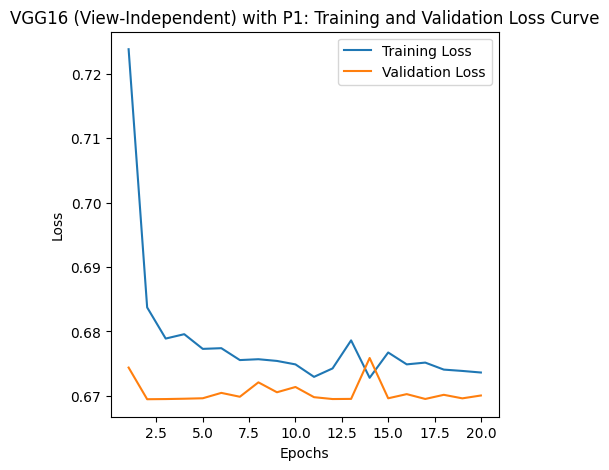

In [ ]:
# Training-Validation Loss curve for P1 pipeline
plot_training_validation_loss(vgg16_p1.history, 'VGG16 (View-Independent)', 'P1')

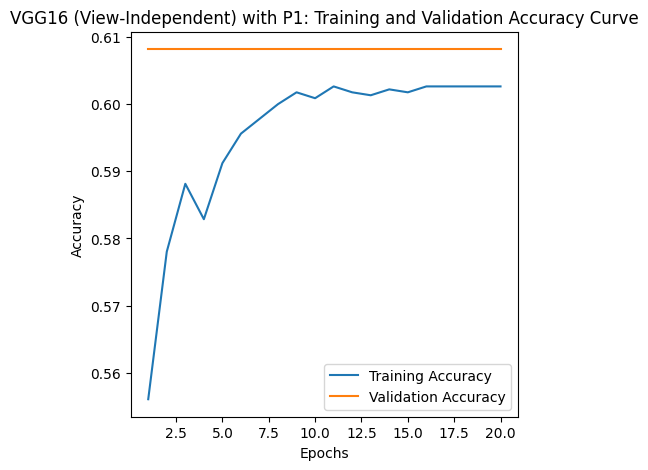

In [ ]:
# Training-Validation Accuracy curve for P1 pipeline
plot_training_validation_accuracy(vgg16_p1.history, 'VGG16 (View-Independent)', 'P1')

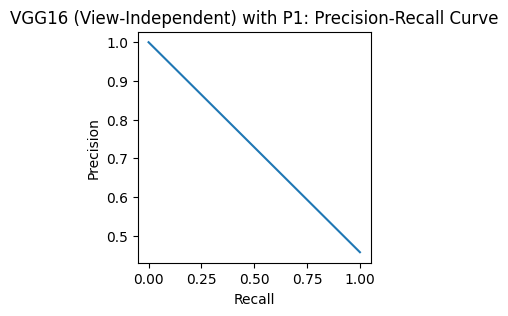

In [ ]:
# Precision-Recall curve for P1 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p1, 'VGG16 (View-Independent)', 'P1')

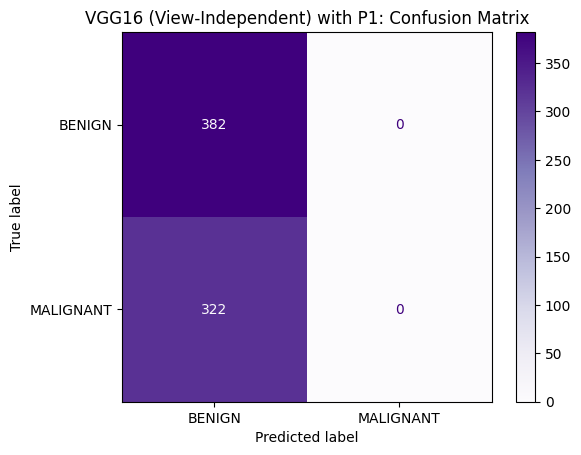

In [ ]:
# Confusion matrix for P1 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p1, 'VGG16 (View-Independent)', 'P1')

## P2 Image Preprocessing Pipeline Experiment

* Resizing
* CLAHE
* Normalization

In [ ]:
# Select the p2 image preprocessor function from the image preprocessor dictionary
p2 = IMAGE_PREPROCESSORS['P2']

In [ ]:
# Create a tf.data dataset with p2 image preprocessing
train_dataset_p2 = generate_dataset(train_df, 32, p2, 'vgg16', training=True)
val_dataset_p2 = generate_dataset(val_df, 32, p2, 'vgg16', training=False)
test_dataset_p2 = generate_dataset(test_df, 32, p2, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p2 pipeline
vgg16_p2 = create_vgg16_model()
vgg16_p2 = compile_model(vgg16_p2)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p2 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p2
train_start_p2 = time.time()

# VGG16 with p2 training for 20 epochs
vgg16_p2.fit(train_dataset_p2, validation_data=val_dataset_p2, epochs=20)

# Memory used in p2
peak_memory_p2 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p2
train_end_p2 = time.time()

# Total training time for p2 in minutes
training_time_p2 = (train_end_p2 - train_start_p2)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 67s 206ms/step - accuracy: 0.5565 - auc: 0.5005 - loss: 0.7236 - precision: 0.3577 - recall: 0.1460 - val_accuracy: 0.6082 - val_auc: 0.4995 - val_loss: 0.6744 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 62s 212ms/step - accuracy: 0.5776 - auc: 0.5055 - loss: 0.6836 - precision: 0.4118 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4966 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 216ms/step - accuracy: 0.5873 - auc: 0.5081 - loss: 0.6789 - precision: 0.4044 - recall: 0.0819 - val_accuracy: 0.6082 - val_auc: 0.5147 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 59s 213ms/step - accuracy: 0.5829 - auc: 0.4958 - loss: 0.6796 - precision: 0.3256 - recall: 0.0465 - val_accuracy: 0.6082 - val_auc: 0.4971 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P2 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p2

# Prediction start time
predict_start_p2 = time.time()

# VGG16 with p2 predictions
prediction_probs_p2 = vgg16_p2.predict(test_dataset_p2)

# Prediction end time
predict_end_p2 = time.time()

# Total prediction time for p2 in seconds
prediction_time_p2 = predict_end_p2 - predict_start_p2

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step


In [ ]:
# Evaluation metrics for VGG16 with p2
eval_metrics_p2 = vgg16_p2.evaluate(test_dataset_p2, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.5426 - auc: 0.5412 - loss: 0.6944 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p2 = np.where(prediction_probs_p2 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p2 true and predicted values
tn_p2, fp_p2, fn_p2, tp_p2 = confusion_matrix(true_pathology, predictions_p2).ravel()

# Compute specificity using CM
specificity_p2 = tn_p2 / (tn_p2 + fp_p2)

# Compute F1 Score using recall and precision
f1_score_p2 = 0.0
if eval_metrics_p2['precision'] + eval_metrics_p2['recall'] != 0.0:
  f1_score_p2 = (2 * eval_metrics_p2['precision'] * eval_metrics_p2['recall']) / (eval_metrics_p2['precision'] + eval_metrics_p2['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p2 = vgg16_p2.count_params()

In [ ]:
# Generate a results dataframe for results of p2 experiment
results_p2 = generate_results_df('VGG16', 'View_Independent', 'P2', eval_metrics_p2, specificity_p2, f1_score_p2, training_time_p2, prediction_time_p2, peak_memory_p2, vgg16_params_p2)

# Store p2 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p2)

Stored results for 0    P2
Name: image_preprocessing_pipeline, dtype: object pipeline


### P2 Image Preprocessing Graphs

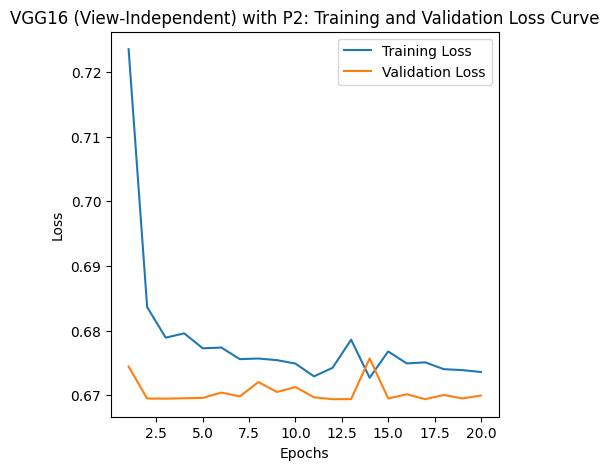

In [ ]:
# Training-Validation Loss curve for P2 pipeline
plot_training_validation_loss(vgg16_p2.history, 'VGG16 (View-Independent)', 'P2')

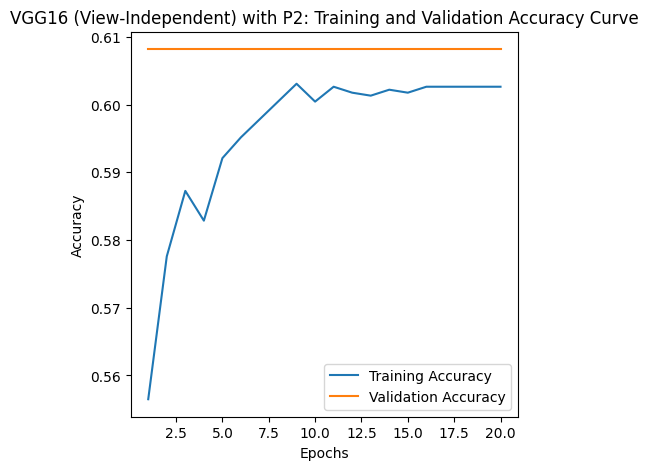

In [ ]:
# Training-Validation Accuracy curve for P2 pipeline
plot_training_validation_accuracy(vgg16_p2.history, 'VGG16 (View-Independent)', 'P2')

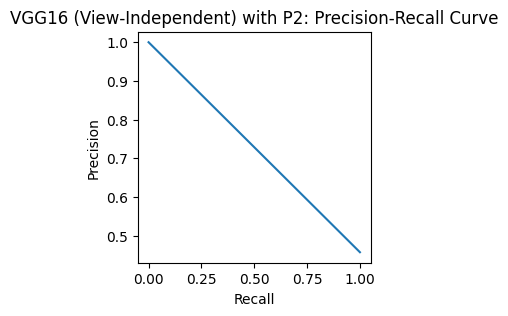

In [ ]:
# Precision-Recall curve for P2 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p2, 'VGG16 (View-Independent)', 'P2')

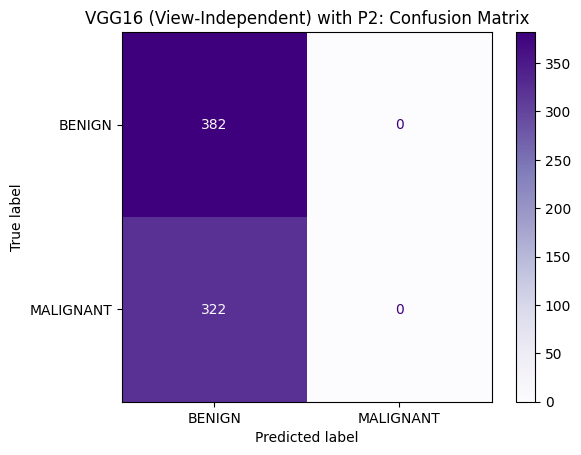

In [ ]:
# Confusion matrix for P2 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p2, 'VGG16 (View-Independent)', 'P2')

## P3 Image Preprocessing Pipeline Experiment

* Resizing
* Gamma Correction
* Normalization

In [ ]:
# Select the p3 image preprocessor function from the image preprocessor dictionary
p3 = IMAGE_PREPROCESSORS['P3']

In [ ]:
# Create a tf.data dataset with p3 image preprocessing
train_dataset_p3 = generate_dataset(train_df, 32, p3, 'vgg16', training=True)
val_dataset_p3 = generate_dataset(val_df, 32, p3, 'vgg16', training=False)
test_dataset_p3 = generate_dataset(test_df, 32, p3, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p3 pipeline
vgg16_p3 = create_vgg16_model()
vgg16_p3 = compile_model(vgg16_p3)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p3 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p3
train_start_p3 = time.time()

# VGG16 with p3 training for 20 epochs
vgg16_p3.fit(train_dataset_p3, validation_data=val_dataset_p3, epochs=20)

# Memory used in p3
peak_memory_p3 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p3
train_end_p3 = time.time()

# Total training time for p3 in minutes
training_time_p3 = (train_end_p3 - train_start_p3)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.5560 - auc: 0.5006 - loss: 0.7237 - precision: 0.3575 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4994 - val_loss: 0.6745 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 62s 207ms/step - accuracy: 0.5785 - auc: 0.5055 - loss: 0.6837 - precision: 0.4149 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.4969 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 215ms/step - accuracy: 0.5877 - auc: 0.5083 - loss: 0.6789 - precision: 0.4076 - recall: 0.0830 - val_accuracy: 0.6082 - val_auc: 0.4966 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 225ms/step - accuracy: 0.5837 - auc: 0.4958 - loss: 0.6796 - precision: 0.3333 - recall: 0.0476 - val_accuracy: 0.6082 - val_auc: 0.4986 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P3 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p3

# Prediction start time
predict_start_p3 = time.time()

# VGG16 with p3 predictions
prediction_probs_p3 = vgg16_p3.predict(test_dataset_p3)

# Prediction end time
predict_end_p3 = time.time()

# Total prediction time for p3 in seconds
prediction_time_p3 = predict_end_p3 - predict_start_p3

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step


In [ ]:
# Evaluation metrics for VGG16 with p3
eval_metrics_p3 = vgg16_p3.evaluate(test_dataset_p3, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.5426 - auc: 0.5000 - loss: 0.6945 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p3 = np.where(prediction_probs_p3 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p3 true and predicted values
tn_p3, fp_p3, fn_p3, tp_p3 = confusion_matrix(true_pathology, predictions_p3).ravel()

# Compute specificity using CM
specificity_p3 = tn_p3 / (tn_p3 + fp_p3)

# Compute F1 Score using recall and precision
f1_score_p3 = 0.0
if eval_metrics_p3['precision'] + eval_metrics_p3['recall'] != 0.0:
  f1_score_p3 = (2 * eval_metrics_p3['precision'] * eval_metrics_p3['recall']) / (eval_metrics_p3['precision'] + eval_metrics_p3['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p3 = vgg16_p3.count_params()

In [ ]:
# Generate a results dataframe for results of p3 experiment
results_p3 = generate_results_df('VGG16', 'View_Independent', 'P3', eval_metrics_p3, specificity_p3, f1_score_p3, training_time_p3, prediction_time_p3, peak_memory_p3, vgg16_params_p3)

# Store p3 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p3)

Stored results for 0    P3
Name: image_preprocessing_pipeline, dtype: object pipeline


### P3 Image Preprocessing Graphs

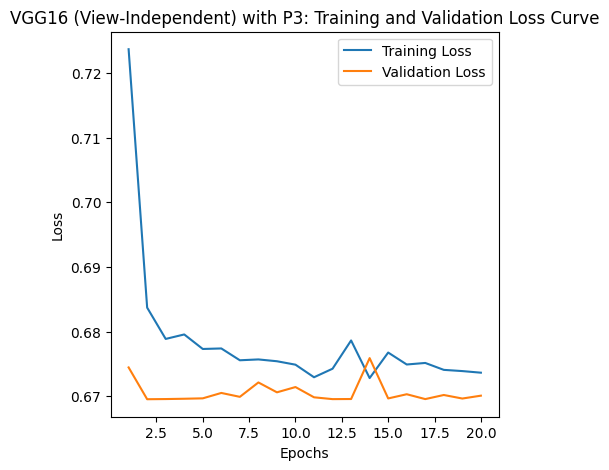

In [ ]:
# Training-Validation Loss curve for P3 pipeline
plot_training_validation_loss(vgg16_p3.history, 'VGG16 (View-Independent)', 'P3')

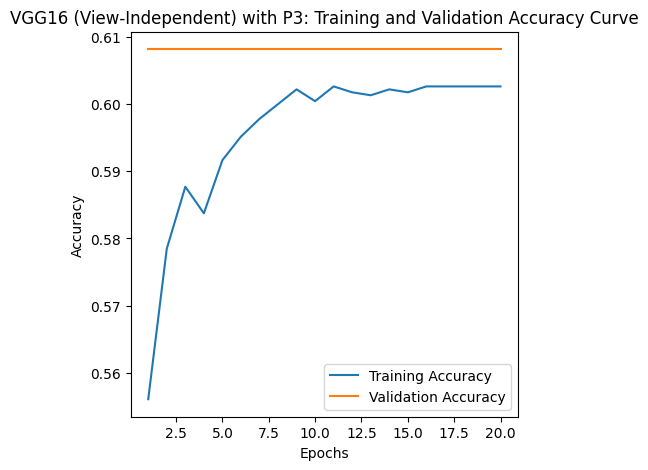

In [ ]:
# Training-Validation Accuracy curve for P3 pipeline
plot_training_validation_accuracy(vgg16_p3.history, 'VGG16 (View-Independent)', 'P3')

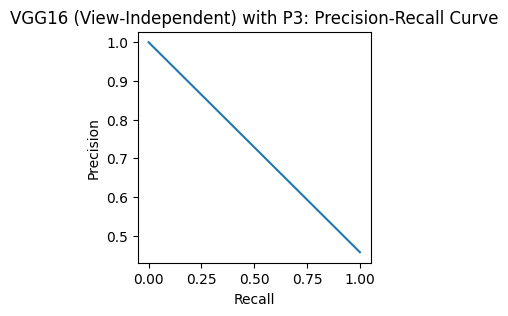

In [ ]:
# Precision-Recall curve for P3 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p3, 'VGG16 (View-Independent)', 'P3')

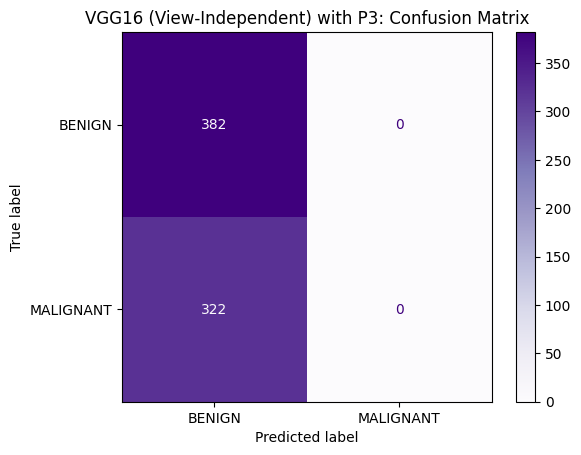

In [ ]:
# Confusion matrix for P3 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p3, 'VGG16 (View-Independent)', 'P3')

## P4 Image Preprocessing Pipeline Experiment

* Resizing
* Median Blur
* Normalization

In [ ]:
# Select the p4 image preprocessor function from the image preprocessor dictionary
p4 = IMAGE_PREPROCESSORS['P4']

In [ ]:
# Create a tf.data dataset with p4 image preprocessing
train_dataset_p4 = generate_dataset(train_df, 32, p4, 'vgg16', training=True)
val_dataset_p4 = generate_dataset(val_df, 32, p4, 'vgg16', training=False)
test_dataset_p4 = generate_dataset(test_df, 32, p4, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p4 pipeline
vgg16_p4 = create_vgg16_model()
vgg16_p4 = compile_model(vgg16_p4)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Train VGG16 with training dataset for p4 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p4
train_start_p4 = time.time()

# VGG16 with p4 training for 20 epochs
vgg16_p4.fit(train_dataset_p4, validation_data=val_dataset_p4, epochs=20)

# Memory used in p4
peak_memory_p4 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p4
train_end_p4 = time.time()

# Total training time for p4 in minutes
training_time_p4 = (train_end_p4 - train_start_p4)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 67s 226ms/step - accuracy: 0.5556 - auc: 0.5007 - loss: 0.7238 - precision: 0.3566 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4973 - val_loss: 0.6744 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 229ms/step - accuracy: 0.5780 - auc: 0.5055 - loss: 0.6838 - precision: 0.4136 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.5075 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 68s 243ms/step - accuracy: 0.5881 - auc: 0.5083 - loss: 0.6789 - precision: 0.4108 - recall: 0.0841 - val_accuracy: 0.6082 - val_auc: 0.4919 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 70s 253ms/step - accuracy: 0.5829 - auc: 0.4957 - loss: 0.6796 - precision: 0.3256 - recall: 0.0465 - val_accuracy: 0.6082 - val_auc: 0.4980 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P4 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p4

# Prediction start time
predict_start_p4 = time.time()

# VGG16 with p4 predictions
prediction_probs_p4 = vgg16_p4.predict(test_dataset_p4)

# Prediction end time
predict_end_p4 = time.time()

# Total prediction time for p4 in seconds
prediction_time_p4 = predict_end_p4 - predict_start_p4

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step


In [ ]:
# Evaluation metrics for VGG16 with p4
eval_metrics_p4 = vgg16_p4.evaluate(test_dataset_p4, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.5426 - auc: 0.5039 - loss: 0.6945 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p4 = np.where(prediction_probs_p4 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p4 true and predicted values
tn_p4, fp_p4, fn_p4, tp_p4 = confusion_matrix(true_pathology, predictions_p4).ravel()

# Compute specificity using CM
specificity_p4 = tn_p4 / (tn_p4 + fp_p4)

# Compute F1 Score using recall and precision
f1_score_p4 = 0.0
if eval_metrics_p4['precision'] + eval_metrics_p4['recall'] != 0.0:
  f1_score_p4 = (2 * eval_metrics_p4['precision'] * eval_metrics_p4['recall']) / (eval_metrics_p4['precision'] + eval_metrics_p4['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p4 = vgg16_p4.count_params()

In [ ]:
# Generate a results dataframe for results of p4 experiment
results_p4 = generate_results_df('VGG16', 'View_Independent', 'P4', eval_metrics_p4, specificity_p4, f1_score_p4, training_time_p4, prediction_time_p4, peak_memory_p4, vgg16_params_p4)

# Store p4 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p4)

Stored results for 0    P4
Name: image_preprocessing_pipeline, dtype: object pipeline


### P4 Image Preprocessing Graphs

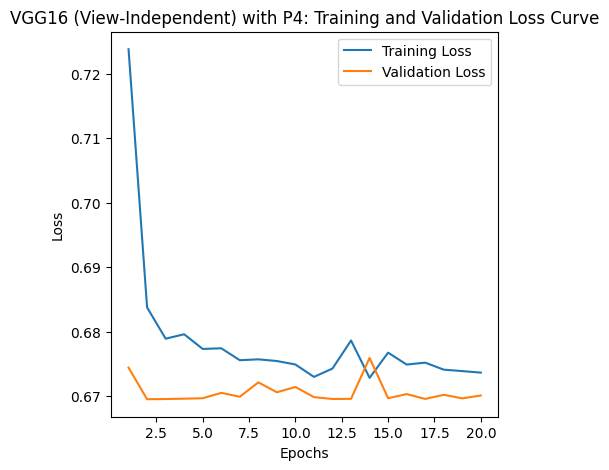

In [ ]:
# Training-Validation Loss curve for P4 pipeline
plot_training_validation_loss(vgg16_p4.history, 'VGG16 (View-Independent)', 'P4')

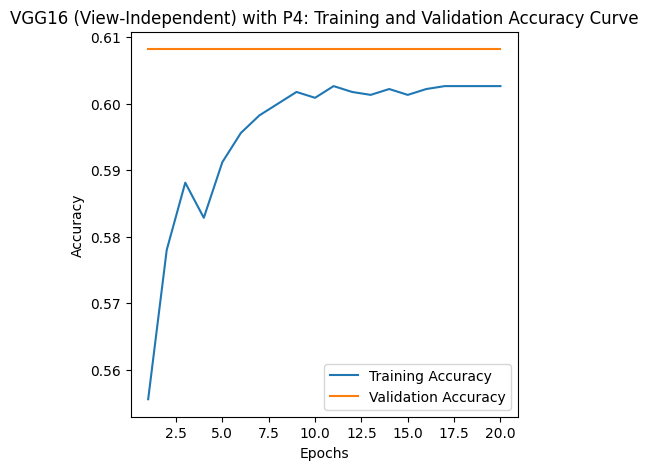

In [ ]:
# Training-Validation Accuracy curve for P4 pipeline
plot_training_validation_accuracy(vgg16_p4.history, 'VGG16 (View-Independent)', 'P4')

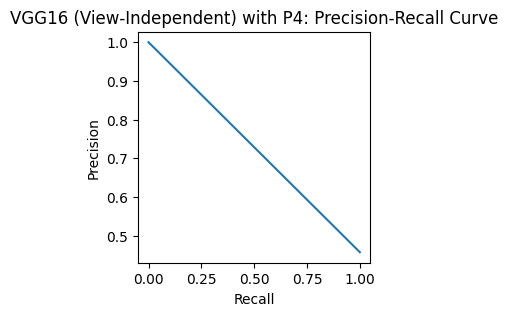

In [ ]:
# Precision-Recall curve for P4 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p4, 'VGG16 (View-Independent)', 'P4')

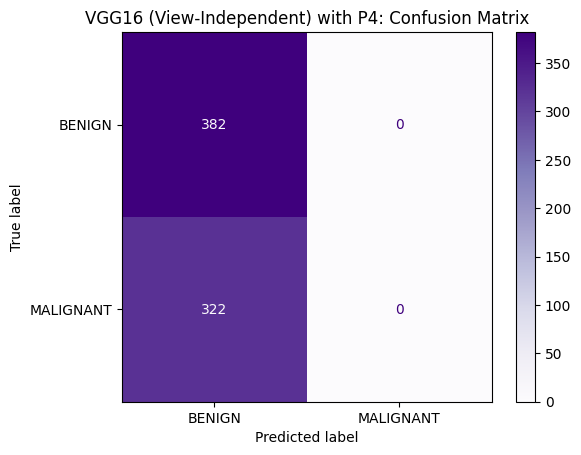

In [ ]:
# Confusion matrix for P4 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p4, 'VGG16 (View-Independent)', 'P4')

## P5 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* Gamma Correction
* Normalization

In [ ]:
# Select the p5 image preprocessor function from the image preprocessor dictionary
p5 = IMAGE_PREPROCESSORS['P5']

In [ ]:
# Create a tf.data dataset with p5 image preprocessing
train_dataset_p5 = generate_dataset(train_df, 32, p5, 'vgg16', training=True)
val_dataset_p5 = generate_dataset(val_df, 32, p5, 'vgg16', training=False)
test_dataset_p5 = generate_dataset(test_df, 32, p5, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p5 pipeline
vgg16_p5 = create_vgg16_model()
vgg16_p5 = compile_model(vgg16_p5)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Train VGG16 with training dataset for p5 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p5
train_start_p5 = time.time()

# VGG16 with p5 training for 20 epochs
vgg16_p5.fit(train_dataset_p5, validation_data=val_dataset_p5, epochs=20)

# Memory used in p5
peak_memory_p5 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p5
train_end_p5 = time.time()

# Total training time for p5 in minutes
training_time_p5 = (train_end_p5 - train_start_p5)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 70s 218ms/step - accuracy: 0.5560 - auc: 0.5006 - loss: 0.7237 - precision: 0.3575 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4994 - val_loss: 0.6745 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 224ms/step - accuracy: 0.5785 - auc: 0.5055 - loss: 0.6837 - precision: 0.4149 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.4969 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 63s 208ms/step - accuracy: 0.5877 - auc: 0.5083 - loss: 0.6789 - precision: 0.4076 - recall: 0.0830 - val_accuracy: 0.6082 - val_auc: 0.4966 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 83s 213ms/step - accuracy: 0.5837 - auc: 0.4958 - loss: 0.6796 - precision: 0.3333 - recall: 0.0476 - val_accuracy: 0.6082 - val_auc: 0.4986 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P5 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p5

# Prediction start time
predict_start_p5 = time.time()

# VGG16 with p5 predictions
prediction_probs_p5 = vgg16_p5.predict(test_dataset_p5)

# Prediction end time
predict_end_p5 = time.time()

# Total prediction time for p5 in seconds
prediction_time_p5 = predict_end_p5 - predict_start_p5

22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step


In [ ]:
# Evaluation metrics for VGG16 with p5
eval_metrics_p5 = vgg16_p5.evaluate(test_dataset_p5, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.5426 - auc: 0.5000 - loss: 0.6945 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p5 = np.where(prediction_probs_p5 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p5 true and predicted values
tn_p5, fp_p5, fn_p5, tp_p5 = confusion_matrix(true_pathology, predictions_p5).ravel()

# Compute specificity using CM
specificity_p5 = tn_p5 / (tn_p5 + fp_p5)

# Compute F1 Score using recall and precision
f1_score_p5 = 0.0
if eval_metrics_p5['precision'] + eval_metrics_p5['recall'] != 0.0:
  f1_score_p5 = (2 * eval_metrics_p5['precision'] * eval_metrics_p5['recall']) / (eval_metrics_p5['precision'] + eval_metrics_p5['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p5 = vgg16_p5.count_params()

In [ ]:
# Generate a results dataframe for results of p5 experiment
results_p5 = generate_results_df('VGG16', 'View_Independent', 'P5', eval_metrics_p5, specificity_p5, f1_score_p5, training_time_p5, prediction_time_p5, peak_memory_p5, vgg16_params_p5)

# Store p5 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p5)

Stored results for 0    P5
Name: image_preprocessing_pipeline, dtype: object pipeline


### P5 Image Preprocessing Graphs

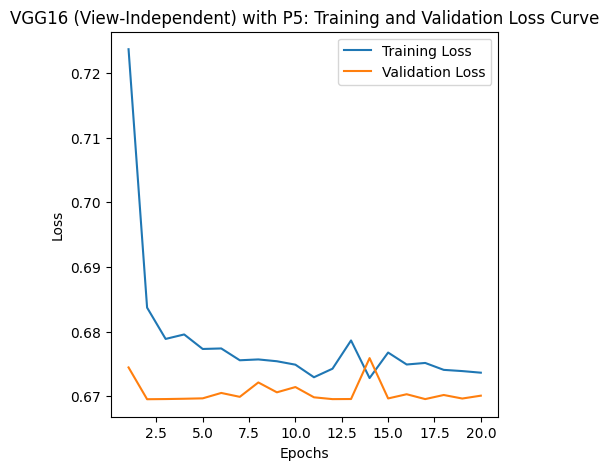

In [ ]:
# Training-Validation Loss curve for P5 pipeline
plot_training_validation_loss(vgg16_p5.history, 'VGG16 (View-Independent)', 'P5')

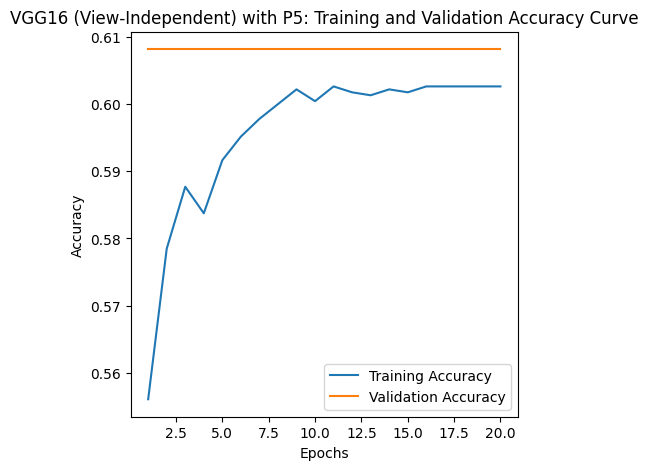

In [ ]:
# Training-Validation Accuracy curve for P5 pipeline
plot_training_validation_accuracy(vgg16_p5.history, 'VGG16 (View-Independent)', 'P5')

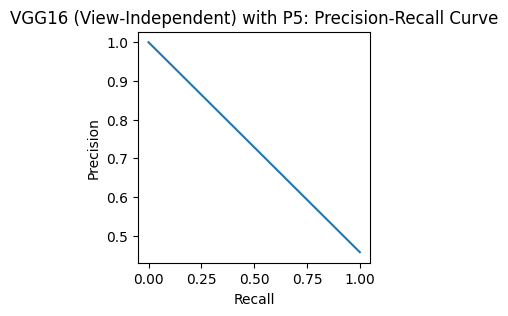

In [ ]:
# Precision-Recall curve for P5 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p5, 'VGG16 (View-Independent)', 'P5')

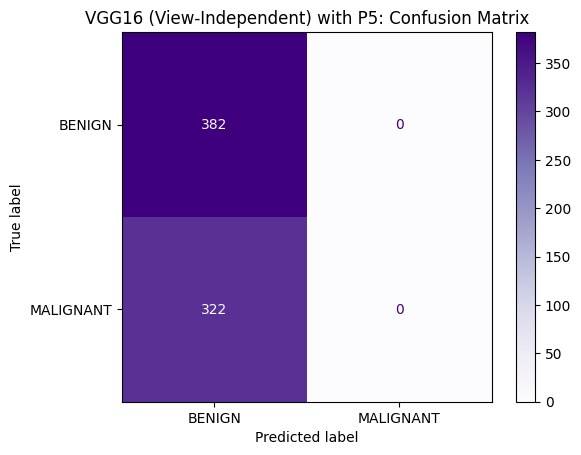

In [ ]:
# Confusion matrix for P5 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p5, 'VGG16 (View-Independent)', 'P5')

## P6 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* Median Blur
* Normalization

In [ ]:
# Select the p6 image preprocessor function from the image preprocessor dictionary
p6 = IMAGE_PREPROCESSORS['P6']

In [ ]:
# Create a tf.data dataset with p6 image preprocessing
train_dataset_p6 = generate_dataset(train_df, 32, p6, 'vgg16', training=True)
val_dataset_p6 = generate_dataset(val_df, 32, p6, 'vgg16', training=False)
test_dataset_p6 = generate_dataset(test_df, 32, p6, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p6 pipeline
vgg16_p6 = create_vgg16_model()
vgg16_p6 = compile_model(vgg16_p6)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p6 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p6
train_start_p6 = time.time()

# VGG16 with p6 training for 20 epochs
vgg16_p6.fit(train_dataset_p6, validation_data=val_dataset_p6, epochs=20)

# Memory used in p6
peak_memory_p6 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p6
train_end_p6 = time.time()

# Total training time for p6 in minutes
training_time_p6 = (train_end_p6 - train_start_p6)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 63s 200ms/step - accuracy: 0.5556 - auc: 0.5007 - loss: 0.7238 - precision: 0.3566 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4973 - val_loss: 0.6744 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 57s 192ms/step - accuracy: 0.5780 - auc: 0.5055 - loss: 0.6838 - precision: 0.4136 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.5075 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 57s 193ms/step - accuracy: 0.5881 - auc: 0.5083 - loss: 0.6789 - precision: 0.4108 - recall: 0.0841 - val_accuracy: 0.6082 - val_auc: 0.4919 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 57s 193ms/step - accuracy: 0.5829 - auc: 0.4957 - loss: 0.6796 - precision: 0.3256 - recall: 0.0465 - val_accuracy: 0.6082 - val_auc: 0.4980 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P6 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p6

# Prediction start time
predict_start_p6 = time.time()

# VGG16 with p6 predictions
prediction_probs_p6 = vgg16_p6.predict(test_dataset_p6)

# Prediction end time
predict_end_p6 = time.time()

# Total prediction time for p6 in seconds
prediction_time_p6 = predict_end_p6 - predict_start_p6

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step


In [ ]:
# Evaluation metrics for VGG16 with p6
eval_metrics_p6 = vgg16_p6.evaluate(test_dataset_p6, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.5426 - auc: 0.5039 - loss: 0.6945 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p6 = np.where(prediction_probs_p6 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p6 true and predicted values
tn_p6, fp_p6, fn_p6, tp_p6 = confusion_matrix(true_pathology, predictions_p6).ravel()

# Compute specificity using CM
specificity_p6 = tn_p6 / (tn_p6 + fp_p6)

# Compute F1 Score using recall and precision
f1_score_p6 = 0.0
if eval_metrics_p6['precision'] + eval_metrics_p6['recall'] != 0.0:
  f1_score_p6 = (2 * eval_metrics_p6['precision'] * eval_metrics_p6['recall']) / (eval_metrics_p6['precision'] + eval_metrics_p6['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p6 = vgg16_p6.count_params()

In [ ]:
# Generate a results dataframe for results of p6 experiment
results_p6 = generate_results_df('VGG16', 'View_Independent', 'P6', eval_metrics_p6, specificity_p6, f1_score_p6, training_time_p6, prediction_time_p6, peak_memory_p6, vgg16_params_p6)

# Store p6 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p6)

Stored results for 0    P6
Name: image_preprocessing_pipeline, dtype: object pipeline


### P6 Image Preprocessing Graphs

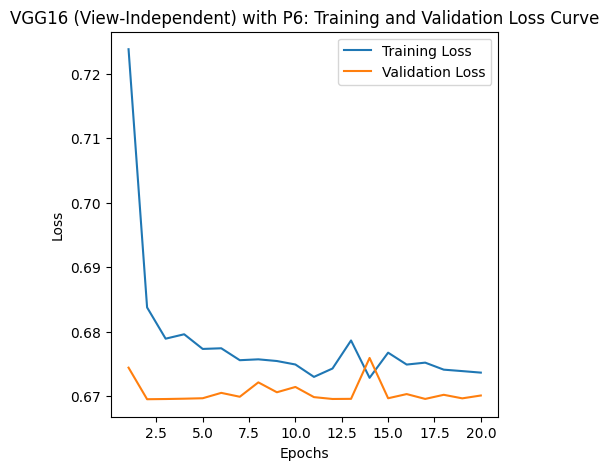

In [ ]:
# Training-Validation Loss curve for P6 pipeline
plot_training_validation_loss(vgg16_p6.history, 'VGG16 (View-Independent)', 'P6')

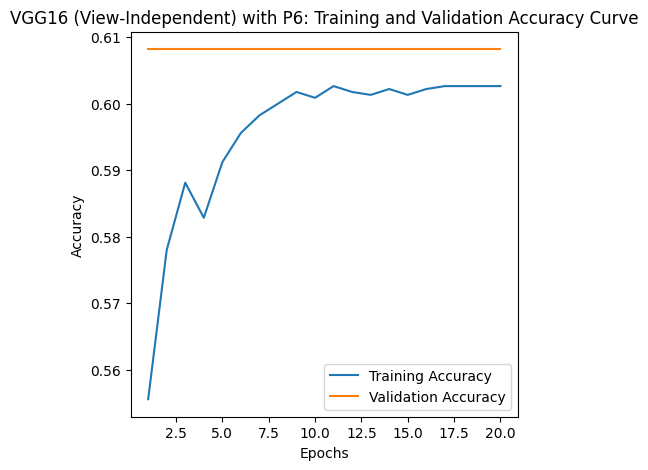

In [ ]:
# Training-Validation Accuracy curve for P6 pipeline
plot_training_validation_accuracy(vgg16_p6.history, 'VGG16 (View-Independent)', 'P6')

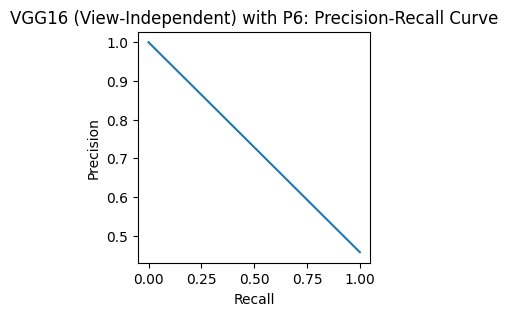

In [ ]:
# Precision-Recall curve for P6 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p6, 'VGG16 (View-Independent)', 'P6')

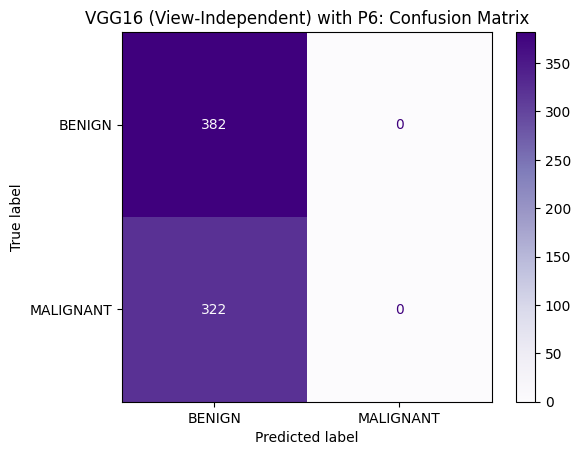

In [ ]:
# Confusion matrix for P6 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p6, 'VGG16 (View-Independent)', 'P6')

## P7 Image Preprocessing Pipeline Experiment

* Resizing
* CLAHE
* Gamma Correction
* Normalization

In [ ]:
# Select the p7 image preprocessor function from the image preprocessor dictionary
p7 = IMAGE_PREPROCESSORS['P7']

In [ ]:
# Create a tf.data dataset with p7 image preprocessing
train_dataset_p7 = generate_dataset(train_df, 32, p7, 'vgg16', training=True)
val_dataset_p7 = generate_dataset(val_df, 32, p7, 'vgg16', training=False)
test_dataset_p7 = generate_dataset(test_df, 32, p7, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p7 pipeline
vgg16_p7 = create_vgg16_model()
vgg16_p7 = compile_model(vgg16_p7)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p7 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p7
train_start_p7 = time.time()

# VGG16 with p7 training for 20 epochs
vgg16_p7.fit(train_dataset_p7, validation_data=val_dataset_p7, epochs=20)

# Memory used in p7
peak_memory_p7 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p7
train_end_p7 = time.time()

# Total training time for p7 in minutes
training_time_p7 = (train_end_p7 - train_start_p7)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 78s 235ms/step - accuracy: 0.5556 - auc: 0.5005 - loss: 0.7235 - precision: 0.3558 - recall: 0.1460 - val_accuracy: 0.6082 - val_auc: 0.4930 - val_loss: 0.6745 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 227ms/step - accuracy: 0.5780 - auc: 0.5057 - loss: 0.6836 - precision: 0.4136 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.4915 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 66s 247ms/step - accuracy: 0.5877 - auc: 0.5083 - loss: 0.6788 - precision: 0.4066 - recall: 0.0819 - val_accuracy: 0.6082 - val_auc: 0.4991 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 67s 272ms/step - accuracy: 0.5829 - auc: 0.4961 - loss: 0.6795 - precision: 0.3256 - recall: 0.0465 - val_accuracy: 0.6082 - val_auc: 0.4978 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P7 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p7

# Prediction start time
predict_start_p7 = time.time()

# VGG16 with p7 predictions
prediction_probs_p7 = vgg16_p7.predict(test_dataset_p7)

# Prediction end time
predict_end_p7 = time.time()

# Total prediction time for p7 in seconds
prediction_time_p7 = predict_end_p7 - predict_start_p7

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step


In [ ]:
# Evaluation metrics for VGG16 with p7
eval_metrics_p7 = vgg16_p7.evaluate(test_dataset_p7, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.5426 - auc: 0.5278 - loss: 0.6944 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p7 = np.where(prediction_probs_p7 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p7 true and predicted values
tn_p7, fp_p7, fn_p7, tp_p7 = confusion_matrix(true_pathology, predictions_p7).ravel()

# Compute specificity using CM
specificity_p7 = tn_p7 / (tn_p7 + fp_p7)

# Compute F1 Score using recall and precision
f1_score_p7 = 0.0
if eval_metrics_p7['precision'] + eval_metrics_p7['recall'] != 0.0:
  f1_score_p7 = (2 * eval_metrics_p7['precision'] * eval_metrics_p7['recall']) / (eval_metrics_p7['precision'] + eval_metrics_p7['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p7 = vgg16_p7.count_params()

In [ ]:
# Generate a results dataframe for results of p7 experiment
results_p7 = generate_results_df('VGG16', 'View_Independent', 'P7', eval_metrics_p7, specificity_p7, f1_score_p7, training_time_p7, prediction_time_p7, peak_memory_p7, vgg16_params_p7)

# Store p7 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p7)

Stored results for 0    P7
Name: image_preprocessing_pipeline, dtype: object pipeline


### P7 Image Preprocessing Graphs

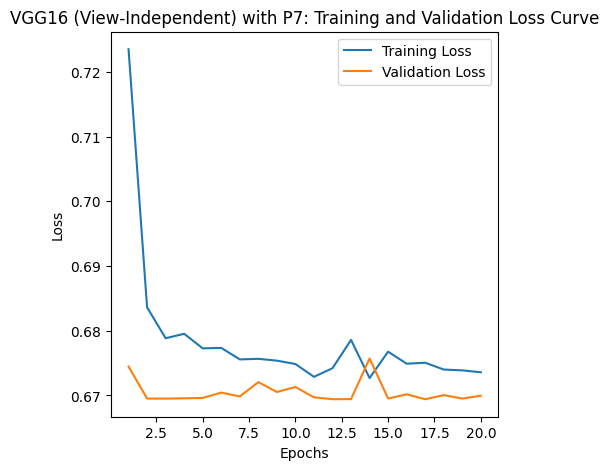

In [ ]:
# Training-Validation Loss curve for P7 pipeline
plot_training_validation_loss(vgg16_p7.history, 'VGG16 (View-Independent)', 'P7')

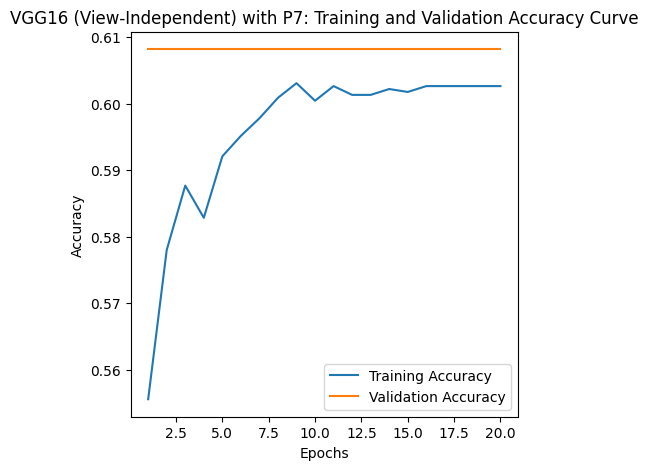

In [ ]:
# Training-Validation Accuracy curve for P7 pipeline
plot_training_validation_accuracy(vgg16_p7.history, 'VGG16 (View-Independent)', 'P7')

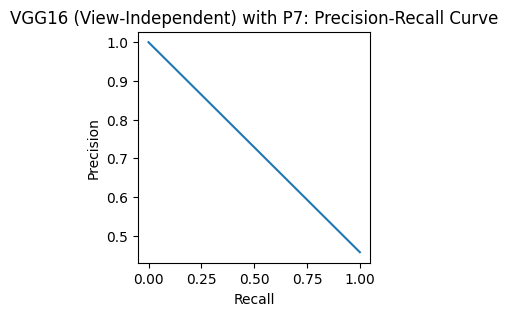

In [ ]:
# Precision-Recall curve for P7 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p7, 'VGG16 (View-Independent)', 'P7')

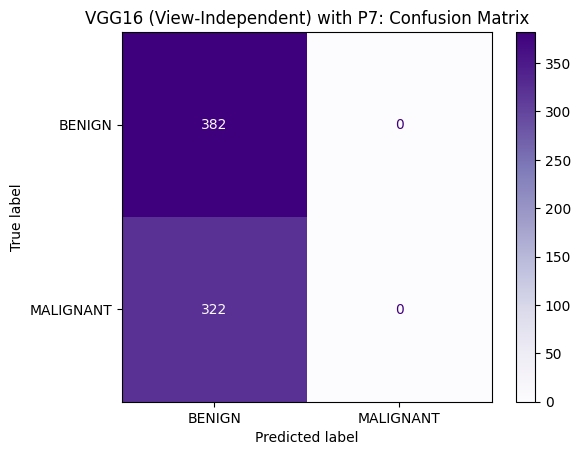

In [ ]:
# Confusion matrix for P7 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p7, 'VGG16 (View-Independent)', 'P7')

## P8 Image Preprocessing Pipeline Experiment

* Resizing
* CLAHE
* Median Blur
* Normalization

In [ ]:
# Select the p8 image preprocessor function from the image preprocessor dictionary
p8 = IMAGE_PREPROCESSORS['P8']

In [ ]:
# Create a tf.data dataset with p8 image preprocessing
train_dataset_p8 = generate_dataset(train_df, 32, p8, 'vgg16', training=True)
val_dataset_p8 = generate_dataset(val_df, 32, p8, 'vgg16', training=False)
test_dataset_p8 = generate_dataset(test_df, 32, p8, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p8 pipeline
vgg16_p8 = create_vgg16_model()
vgg16_p8 = compile_model(vgg16_p8)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Train VGG16 with training dataset for p8 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p8
train_start_p8 = time.time()

# VGG16 with p8 training for 20 epochs
vgg16_p8.fit(train_dataset_p8, validation_data=val_dataset_p8, epochs=20)

# Memory used in p8
peak_memory_p8 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p8
train_end_p8 = time.time()

# Total training time for p8 in minutes
training_time_p8 = (train_end_p8 - train_start_p8)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 69s 278ms/step - accuracy: 0.5565 - auc: 0.5005 - loss: 0.7237 - precision: 0.3585 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4995 - val_loss: 0.6744 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 74s 215ms/step - accuracy: 0.5780 - auc: 0.5058 - loss: 0.6837 - precision: 0.4136 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.4974 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 59s 216ms/step - accuracy: 0.5881 - auc: 0.5083 - loss: 0.6789 - precision: 0.4108 - recall: 0.0841 - val_accuracy: 0.6082 - val_auc: 0.5067 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 63s 270ms/step - accuracy: 0.5829 - auc: 0.4962 - loss: 0.6796 - precision: 0.3256 - recall: 0.0465 - val_accuracy: 0.6082 - val_auc: 0.4978 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P8 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p8

# Prediction start time
predict_start_p8 = time.time()

# VGG16 with p8 predictions
prediction_probs_p8 = vgg16_p8.predict(test_dataset_p8)

# Prediction end time
predict_end_p8 = time.time()

# Total prediction time for p8 in seconds
prediction_time_p8 = predict_end_p8 - predict_start_p8

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step


In [ ]:
# Evaluation metrics for VGG16 with p8
eval_metrics_p8 = vgg16_p8.evaluate(test_dataset_p8, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.5426 - auc: 0.5050 - loss: 0.6944 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p8 = np.where(prediction_probs_p8 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p8 true and predicted values
tn_p8, fp_p8, fn_p8, tp_p8 = confusion_matrix(true_pathology, predictions_p8).ravel()

# Compute specificity using CM
specificity_p8 = tn_p8 / (tn_p8 + fp_p8)

# Compute F1 Score using recall and precision
f1_score_p8 = 0.0
if eval_metrics_p8['precision'] + eval_metrics_p8['recall'] != 0.0:
  f1_score_p8 = (2 * eval_metrics_p8['precision'] * eval_metrics_p8['recall']) / (eval_metrics_p8['precision'] + eval_metrics_p8['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p8 = vgg16_p8.count_params()

In [ ]:
# Generate a results dataframe for results of p8 experiment
results_p8 = generate_results_df('VGG16', 'View_Independent', 'P8', eval_metrics_p8, specificity_p8, f1_score_p8, training_time_p8, prediction_time_p8, peak_memory_p8, vgg16_params_p8)

# Store p8 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p8)

Stored results for 0    P8
Name: image_preprocessing_pipeline, dtype: object pipeline


### P8 Image Preprocessing Graphs

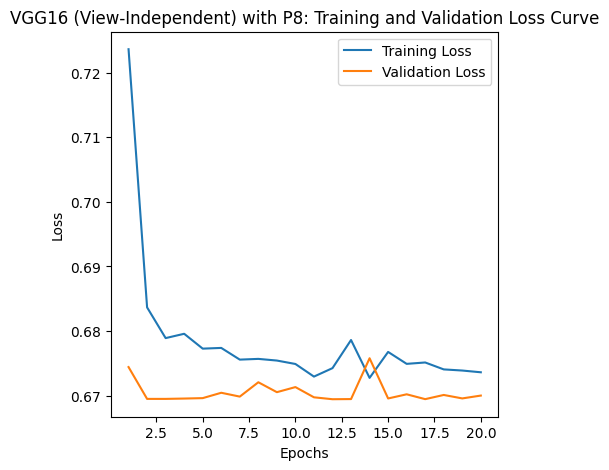

In [ ]:
# Training-Validation Loss curve for P8 pipeline
plot_training_validation_loss(vgg16_p8.history, 'VGG16 (View-Independent)', 'P8')

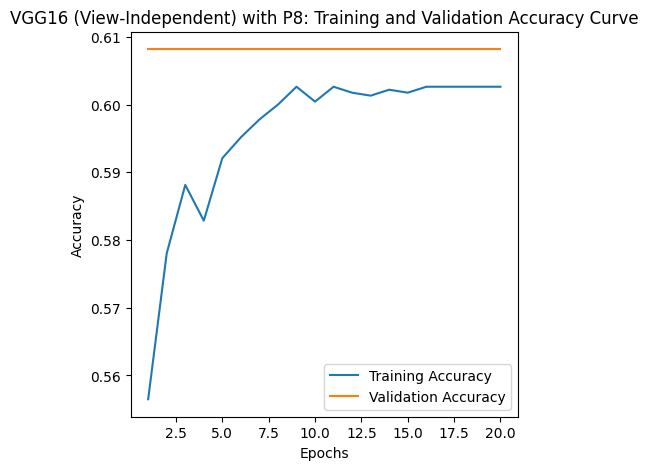

In [ ]:
# Training-Validation Accuracy curve for P8 pipeline
plot_training_validation_accuracy(vgg16_p8.history, 'VGG16 (View-Independent)', 'P8')

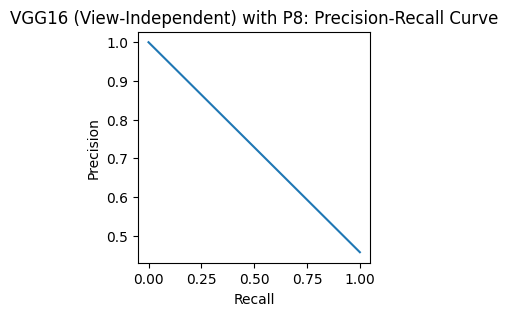

In [ ]:
# Precision-Recall curve for P8 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p8, 'VGG16 (View-Independent)', 'P8')

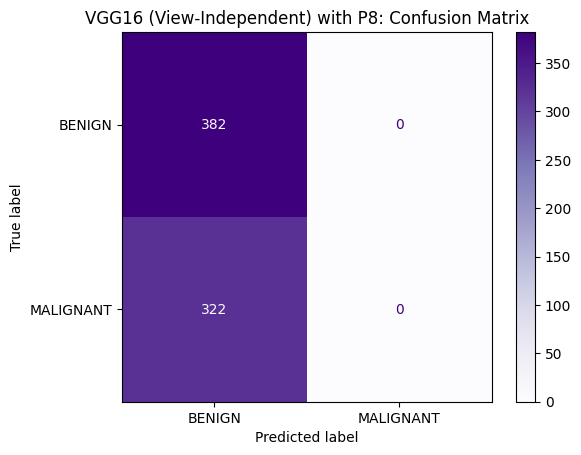

In [ ]:
# Confusion matrix for P8 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p8, 'VGG16 (View-Independent)', 'P8')

## P9 Image Preprocessing Pipeline Experiment

* Resizing
* Gamma Correction
* Median Blur
* Normalization

In [ ]:
# Select the p9 image preprocessor function from the image preprocessor dictionary
p9 = IMAGE_PREPROCESSORS['P9']

In [ ]:
# Create a tf.data dataset with p9 image preprocessing
train_dataset_p9 = generate_dataset(train_df, 32, p9, 'vgg16', training=True)
val_dataset_p9 = generate_dataset(val_df, 32, p9, 'vgg16', training=False)
test_dataset_p9 = generate_dataset(test_df, 32, p9, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p9 pipeline
vgg16_p9 = create_vgg16_model()
vgg16_p9 = compile_model(vgg16_p9)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p9 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p9
train_start_p9 = time.time()

# VGG16 with p9 training for 20 epochs
vgg16_p9.fit(train_dataset_p9, validation_data=val_dataset_p9, epochs=20)

# Memory used in p9
peak_memory_p9 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p9
train_end_p9 = time.time()

# Total training time for p9 in minutes
training_time_p9 = (train_end_p9 - train_start_p9)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 205ms/step - accuracy: 0.5560 - auc: 0.5008 - loss: 0.7237 - precision: 0.3575 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4994 - val_loss: 0.6745 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 57s 196ms/step - accuracy: 0.5785 - auc: 0.5055 - loss: 0.6837 - precision: 0.4149 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.4963 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 57s 199ms/step - accuracy: 0.5877 - auc: 0.5083 - loss: 0.6789 - precision: 0.4076 - recall: 0.0830 - val_accuracy: 0.6082 - val_auc: 0.4980 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 58s 196ms/step - accuracy: 0.5837 - auc: 0.4960 - loss: 0.6796 - precision: 0.3333 - recall: 0.0476 - val_accuracy: 0.6082 - val_auc: 0.4986 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P9 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p9

# Prediction start time
predict_start_p9 = time.time()

# VGG16 with p9 predictions
prediction_probs_p9 = vgg16_p9.predict(test_dataset_p9)

# Prediction end time
predict_end_p9 = time.time()

# Total prediction time for p9 in seconds
prediction_time_p9 = predict_end_p9 - predict_start_p9

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step


In [ ]:
# Evaluation metrics for VGG16 with p9
eval_metrics_p9 = vgg16_p9.evaluate(test_dataset_p9, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.5426 - auc: 0.5000 - loss: 0.6945 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p9 = np.where(prediction_probs_p9 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p9 true and predicted values
tn_p9, fp_p9, fn_p9, tp_p9 = confusion_matrix(true_pathology, predictions_p9).ravel()

# Compute specificity using CM
specificity_p9 = tn_p9 / (tn_p9 + fp_p9)

# Compute F1 Score using recall and precision
f1_score_p9 = 0.0
if eval_metrics_p9['precision'] + eval_metrics_p9['recall'] != 0.0:
  f1_score_p9 = (2 * eval_metrics_p9['precision'] * eval_metrics_p9['recall']) / (eval_metrics_p9['precision'] + eval_metrics_p9['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p9 = vgg16_p9.count_params()

In [ ]:
# Generate a results dataframe for results of p9 experiment
results_p9 = generate_results_df('VGG16', 'View_Independent', 'P9', eval_metrics_p9, specificity_p9, f1_score_p9, training_time_p9, prediction_time_p9, peak_memory_p9, vgg16_params_p9)

# Store p9 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p9)

Stored results for 0    P9
Name: image_preprocessing_pipeline, dtype: object pipeline


### P9 Image Preprocessing Graphs

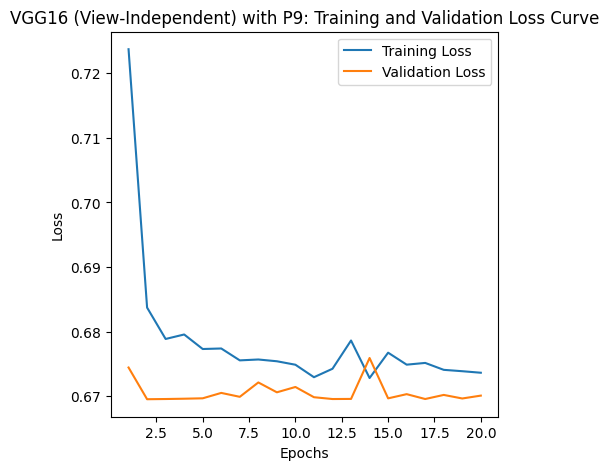

In [ ]:
# Training-Validation Loss curve for P9 pipeline
plot_training_validation_loss(vgg16_p9.history, 'VGG16 (View-Independent)', 'P9')

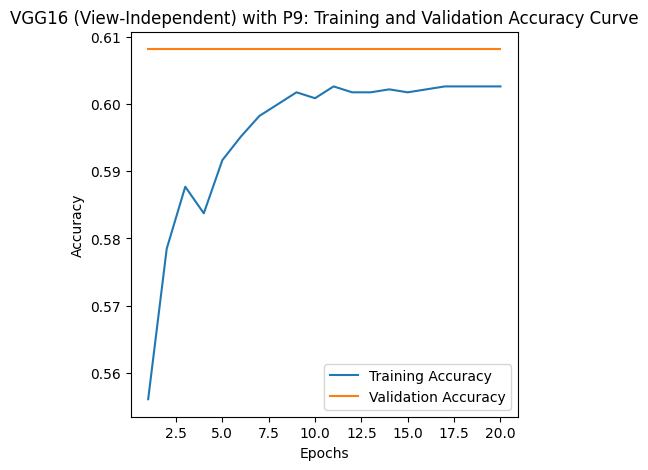

In [ ]:
# Training-Validation Accuracy curve for P9 pipeline
plot_training_validation_accuracy(vgg16_p9.history, 'VGG16 (View-Independent)', 'P9')

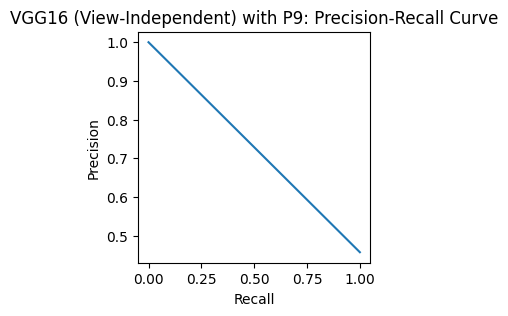

In [ ]:
# Precision-Recall curve for P9 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p9, 'VGG16 (View-Independent)', 'P9')

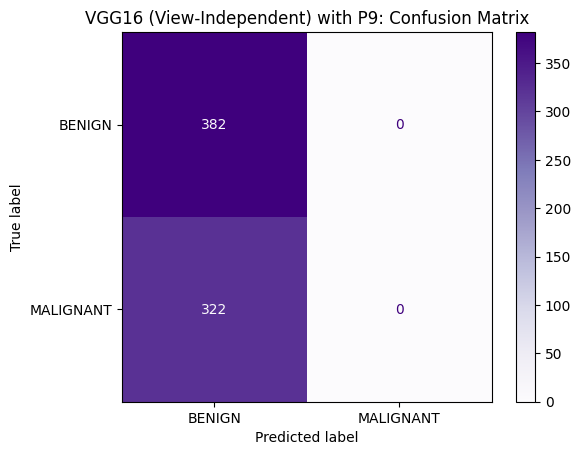

In [ ]:
# Confusion matrix for P9 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p9, 'VGG16 (View-Independent)', 'P9')

## P10 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* CLAHE
* Gamma Correction
* Median Blur
* Normalization

In [ ]:
# Select the p10 image preprocessor function from the image preprocessor dictionary
p10 = IMAGE_PREPROCESSORS['P10']

In [ ]:
# Create a tf.data dataset with p10 image preprocessing
train_dataset_p10 = generate_dataset(train_df, 32, p10, 'vgg16', training=True)
val_dataset_p10 = generate_dataset(val_df, 32, p10, 'vgg16', training=False)
test_dataset_p10 = generate_dataset(test_df, 32, p10, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p10 pipeline
vgg16_p10 = create_vgg16_model()
vgg16_p10 = compile_model(vgg16_p10)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p10 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p10
train_start_p10 = time.time()

# VGG16 with p10 training for 20 epochs
vgg16_p10.fit(train_dataset_p10, validation_data=val_dataset_p10, epochs=20)

# Memory used in p10
peak_memory_p10 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p10
train_end_p10 = time.time()

# Total training time for p10 in minutes
training_time_p10 = (train_end_p10 - train_start_p10)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 68s 229ms/step - accuracy: 0.5560 - auc: 0.5006 - loss: 0.7236 - precision: 0.3575 - recall: 0.1471 - val_accuracy: 0.6082 - val_auc: 0.4944 - val_loss: 0.6745 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 214ms/step - accuracy: 0.5780 - auc: 0.5058 - loss: 0.6837 - precision: 0.4136 - recall: 0.1482 - val_accuracy: 0.6082 - val_auc: 0.4892 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 208ms/step - accuracy: 0.5881 - auc: 0.5083 - loss: 0.6789 - precision: 0.4098 - recall: 0.0830 - val_accuracy: 0.6082 - val_auc: 0.5037 - val_loss: 0.6695 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 210ms/step - accuracy: 0.5824 - auc: 0.4958 - loss: 0.6795 - precision: 0.3231 - recall: 0.0465 - val_accuracy: 0.6082 - val_auc: 0.4964 - val_loss: 0.6696 - val_precision: 0.0000e+00 - val_recall: 0.0000e

### P10 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p10

# Prediction start time
predict_start_p10 = time.time()

# VGG16 with p10 predictions
prediction_probs_p10 = vgg16_p10.predict(test_dataset_p10)

# Prediction end time
predict_end_p10 = time.time()

# Total prediction time for p10 in seconds
prediction_time_p10 = predict_end_p10 - predict_start_p10

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step


In [ ]:
# Evaluation metrics for VGG16 with p10
eval_metrics_p10 = vgg16_p10.evaluate(test_dataset_p10, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.5426 - auc: 0.5000 - loss: 0.6944 - precision: 0.0000e+00 - recall: 0.0000e+00


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p10 = np.where(prediction_probs_p10 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p10 true and predicted values
tn_p10, fp_p10, fn_p10, tp_p10 = confusion_matrix(true_pathology, predictions_p10).ravel()

# Compute specificity using CM
specificity_p10 = tn_p10 / (tn_p10 + fp_p10)

# Compute F1 Score using recall and precision
f1_score_p10 = 0.0
if eval_metrics_p10['precision'] + eval_metrics_p10['recall'] != 0.0:
  f1_score_p10 = (2 * eval_metrics_p10['precision'] * eval_metrics_p10['recall']) / (eval_metrics_p10['precision'] + eval_metrics_p10['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p10 = vgg16_p10.count_params()

In [ ]:
# Generate a results dataframe for results of p10 experiment
results_p10 = generate_results_df('VGG16', 'View_Independent', 'P10', eval_metrics_p10, specificity_p10, f1_score_p10, training_time_p10, prediction_time_p10, peak_memory_p10, vgg16_params_p10)

# Store p10 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p10)

Stored results for 0    P10
Name: image_preprocessing_pipeline, dtype: object pipeline


### P10 Image Preprocessing Graphs

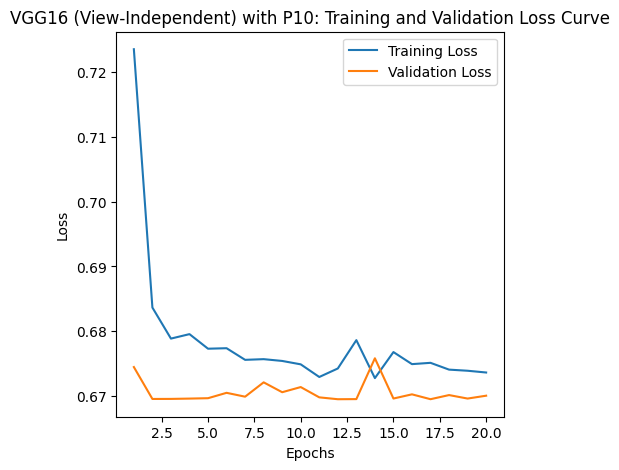

In [ ]:
# Training-Validation Loss curve for P10 pipeline
plot_training_validation_loss(vgg16_p10.history, 'VGG16 (View-Independent)', 'P10')

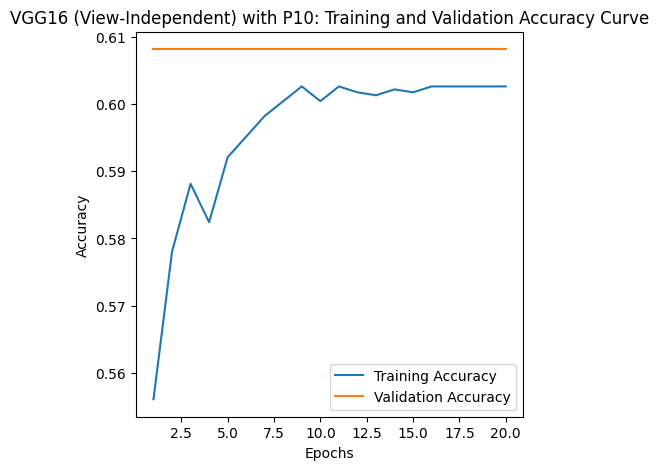

In [ ]:
# Training-Validation Accuracy curve for P10 pipeline
plot_training_validation_accuracy(vgg16_p10.history, 'VGG16 (View-Independent)', 'P10')

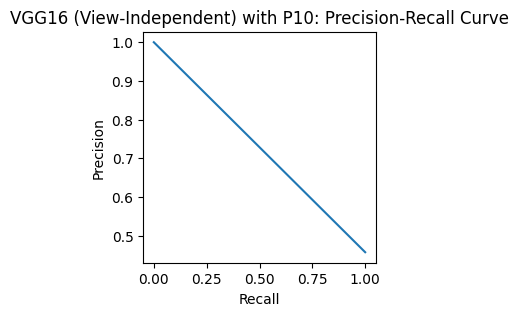

In [ ]:
# Precision-Recall curve for P10 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p10, 'VGG16 (View-Independent)', 'P10')

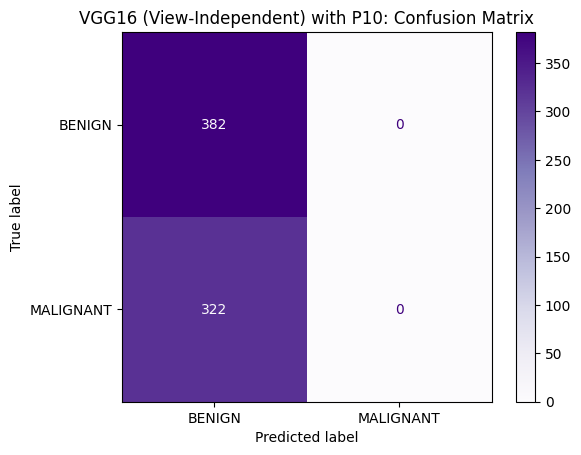

In [ ]:
# Confusion matrix for P10 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p10, 'VGG16 (View-Independent)', 'P10')